In [48]:
# Importa le librerie necessarie
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import os
import random
from skimage.util import random_noise
from os import listdir
import tarfile
import zipfile
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.data.experimental import AUTOTUNE
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Layer, Conv2D, Add, ReLU, Concatenate, GlobalAveragePooling2D, Multiply, Input, Lambda,  MaxPooling2D, UpSampling2D, Activation
from tensorflow.keras.models import Model
import tensorflow_datasets as tfds
from tensorflow.keras.saving import register_keras_serializable
from keras.models import load_model
from sklearn.model_selection import train_test_split
from io import BytesIO

In [49]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [50]:

def plot_denoising_results(x_test_noisy, decoded1, decoded2, x_test, n=10):
    """
    Visualizza n immagini: rumorose, denoised da due modelli diversi, e originali.
    """
    plt.figure(figsize=(20, 8))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(4, n, i + 1)
        plt.imshow(x_test_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Denoised - modello 1
        ax = plt.subplot(4, n, i + 1 + n)
        plt.imshow(decoded1[i])
        plt.title("Denoised Rident")
        plt.axis('off')

        # Denoised - modello 2
        ax = plt.subplot(4, n, i + 1 + 2 * n)
        plt.imshow(decoded2[i])
        plt.title("Denoised AE")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(4, n, i + 1 + 3 * n)
        plt.imshow(x_test[i])
        plt.title("Originale")
        plt.axis('off')

    plt.tight_layout()
    plt.show()



In [51]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [52]:
# MeanShift: sottrae (o aggiunge) la media RGB
@register_keras_serializable("MeanShift")
class MeanShift(Layer):
    def __init__(self, rgb_mean, sign=-1, **kwargs):
        """
        rgb_mean: tupla con la media dei canali R, G, B.
        sign: -1 per sottrarre la media, 1 per aggiungerla.
        """
        super(MeanShift, self).__init__(**kwargs)
        self.rgb_mean = tf.constant(rgb_mean, dtype=tf.float32)
        self.sign = sign

    def call(self, x):
        # x è atteso in formato (batch, altezza, larghezza, 3)
        # Sfruttiamo Lambda per eseguire l'operazione per ogni elemento
        # Nota: non stiamo scalando per std in questo esempio
        return x + self.sign * self.rgb_mean

# BasicBlock: Conv2D seguita da attivazione ReLU
@register_keras_serializable("BasicBlock")
class BasicBlock(Layer):
    def __init__(self, out_channels, kernel_size=3, stride=1, use_bias=False, **kwargs):
        super(BasicBlock, self).__init__(**kwargs)
        self.conv = Conv2D(out_channels, kernel_size, strides=stride,
                           padding='same', use_bias=use_bias)
        self.relu = ReLU()

    def call(self, x):
        return self.relu(self.conv(x))

# ResidualBlock: due convoluzioni con skip connection(come lavora cuda con 2 thread -> 2 filtri applicati e poi si uniscono i risultati)
@register_keras_serializable("ResidualBlock")
class ResidualBlock(Layer):
    def __init__(self, out_channels, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        self.conv1 = Conv2D(out_channels, 3, strides=1, padding='same')
        self.relu = ReLU()
        self.conv2 = Conv2D(out_channels, 3, strides=1, padding='same')

    def call(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        out = Add()([x, residual])
        return ReLU()(out)

# EResidualBlock: versione estesa con convoluzioni a gruppi
@register_keras_serializable("EResidualBlock")
class EResidualBlock(Layer):
    def __init__(self, out_channels, groups=1, **kwargs):
        super(EResidualBlock, self).__init__(**kwargs)
        self.conv1 = Conv2D(out_channels, 3, strides=1, padding='same', groups=groups)
        self.relu = ReLU()
        self.conv2 = Conv2D(out_channels, 3, strides=1, padding='same', groups=groups)
        self.conv3 = Conv2D(out_channels, 1, strides=1, padding='valid')

    def call(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        residual = self.relu(residual)
        residual = self.conv3(residual)
        out = Add()([x, residual])
        return ReLU()(out)

# Merge_Run_dual: due rami convoluzionali con dilatazioni diverse, poi fusione e skip connection
@register_keras_serializable("MergeRunDual")
class MergeRunDual(Layer):
    def __init__(self, out_channels, **kwargs):
        super(MergeRunDual, self).__init__(**kwargs)
        # Primo ramo
        self.conv1a = Conv2D(out_channels, 3, strides=1, padding='same')
        self.relu1a = ReLU()
        self.conv1b = Conv2D(out_channels, 3, strides=1, padding='same', dilation_rate=2)
        self.relu1b = ReLU()
        # Secondo ramo
        self.conv2a = Conv2D(out_channels, 3, strides=1, padding='same', dilation_rate=3)
        self.relu2a = ReLU()
        self.conv2b = Conv2D(out_channels, 3, strides=1, padding='same', dilation_rate=4)
        self.relu2b = ReLU()
        # Gogeta
        self.conv3 = Conv2D(out_channels, 3, strides=1, padding='same')
        self.relu3 = ReLU()

    def call(self, x):
        branch1 = self.relu1a(self.conv1a(x))
        branch1 = self.relu1b(self.conv1b(branch1))

        branch2 = self.relu2a(self.conv2a(x))
        branch2 = self.relu2b(self.conv2b(branch2))

        merged = Concatenate()([branch1, branch2])
        merged = self.relu3(self.conv3(merged))
        return Add()([merged, x])

# CALayer: Channel Attention Layer
@register_keras_serializable("CALayer")
class CALayer(Layer):
    def __init__(self, channel, reduction=16, **kwargs):
        super(CALayer, self).__init__(**kwargs)
        self.channel = channel
        self.reduction = reduction
        self.conv1 = Conv2D(channel // reduction, 1, strides=1, padding='same')
        self.relu = ReLU()
        self.conv2 = Conv2D(channel, 1, strides=1, padding='same', activation='sigmoid') #sigmoid: risultato tra 0 e 1

    def call(self, x):
        # Calcolo della media globale per canale
        y = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        y = self.relu(self.conv1(y))
        y = self.conv2(y)
        return Multiply()([x, y])

# Block: combinazione di MergeRunDual, ResidualBlock, EResidualBlock e CALayer
@register_keras_serializable("Block")
class Block(Layer):
    def __init__(self, out_channels, **kwargs):
        super(Block, self).__init__(**kwargs)
        self.merge_run_dual = MergeRunDual(out_channels)
        self.residual_block = ResidualBlock(out_channels)
        self.e_residual_block = EResidualBlock(out_channels)
        self.ca = CALayer(out_channels)

    def call(self, x):
        r1 = self.merge_run_dual(x)
        r2 = self.residual_block(r1)
        r3 = self.e_residual_block(r2)
        out = self.ca(r3)
        return out

# RIDNET: il modello final
@register_keras_serializable("RIDNET")
def RIDNET(n_feats=64, rgb_range=1.0):
    """
    n_feats: numero di feature channels usate all'interno del modello.<br>
    rgb_range: scala dei valori RGB (ad es. 1.0 se l'input è normalizzato [0,1]).
    """
    rgb_mean = (0.4488, 0.4371, 0.4040)

    input_layer = Input(shape=(None, None, 3))

    # Sottosottrai la media (MeanShift con sign=-1)
    sub_mean = MeanShift(rgb_mean, sign=-1)
    x = sub_mean(input_layer)

    # Testa: BasicBlock (conv + ReLU)
    head = Conv2D(n_feats, 3, strides=1, padding='same', activation='relu')(x)

    # Serie di blocchi
    b1 = Block(n_feats)(head)
    b2 = Block(n_feats)(b1)
    b3 = Block(n_feats)(b2)
    b4 = Block(n_feats)(b3)

    # Coda: convoluzione finale per ottenere 3 canali
    tail = Conv2D(3, 3, strides=1, padding='same')(b4)

    # Aggiungi la media (MeanShift con sign=+1)
    add_mean = MeanShift(rgb_mean, sign=1)
    res = add_mean(tail)

    # Connessione residua a livello di immagine: somma con l'input originale
    output = Add()([res, input_layer])

    model = Model(inputs=input_layer, outputs=output)
    return model

In [53]:
def extract_kvasir_zip(zip_path, extract_path="./kvasir_seg"):
    """
    Estrae un file ZIP contenente il dataset Kvasir.
    """
    os.makedirs(extract_path, exist_ok=True)

    print("Estrazione del dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(path=extract_path)
    print("Estrazione completata!")

def load_kvasir_images(dataset_path, img_size=(224, 224)):
    """
    Carica le immagini dal dataset estratto.
    """
    images = []

    for img in listdir(dataset_path):
        img_path = dataset_path + "/" + img
        imgs = load_img(img_path, target_size=img_size)
        img_array = img_to_array(imgs).astype('float32') / 255.0  # Normalizzazione
        images.append(img_array)

    return np.array(images)

def split_dataset(images, labels=None, test_size=0.2, val_size=0.1):
    """
    Suddivide il dataset in training, validation e test set.
    """
    # If labels are not provided, assume unsupervised learning and create dummy labels
    if labels is None:
        labels = np.zeros(len(images))  # Create dummy labels for unsupervised task

    x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=test_size, random_state=42)
    x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=val_size / (1 - test_size), random_state=42)

    return x_train, x_val, x_test, y_train, y_val, y_test

In [54]:
def preprocess(sample, img_size=(256, 256)):
    """
    Preprocessa una singola immagine:
      - Normalizza (0, 1)
      - Ridimensiona a img_size
    """
    image = tf.cast(sample['image'], tf.float32) / 255.0
    image = tf.image.resize(image, img_size)
    return image

def load_dataset(split='train', img_size=(256,256), batch_size=16):
    """
    Carica il dataset Oxford-IIIT Pet da tfds e applica il preprocessamento.
    Ritorna un dataset in batch.
    """
    ds_split = 'train[:80%]'
    if(split == 'validation'):
      ds_split = 'train[80%:]'
    elif(split != 'train' or split != 'validation'):
      ds_split = 'test'

    dataset = tfds.load('oxford_iiit_pet', split=ds_split, as_supervised=False)  # as_supervised=False per mantenere dict
    dataset = dataset.map(lambda sample: preprocess(sample, img_size))  # Preprocessing
    dataset = dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # Ottimizza il caricamento
    return dataset

In [55]:

def add_noise_2(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

def add_noise(x):
    noise_levels = [0.1, 0.2, 0.3, 0.4]
    noise_factor = tf.random.shuffle(noise_levels)[0]  # scegli uno random tra i 4
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

In [56]:
# Parametri
img_size = (112, 112)
batch_size = 64
noise_factor = 0.4
epochs = 50

In [57]:
zip_path = "./kvasir-seg.zip"  # Percorso del file ZIP
extract_kvasir_zip(zip_path)

Estrazione del dataset...
Estrazione completata!


In [58]:
kvasir_dataset = load_kvasir_images("./kvasir_seg/Kvasir-SEG/images", img_size)

In [59]:
kvasir_noise = add_noise(kvasir_dataset)

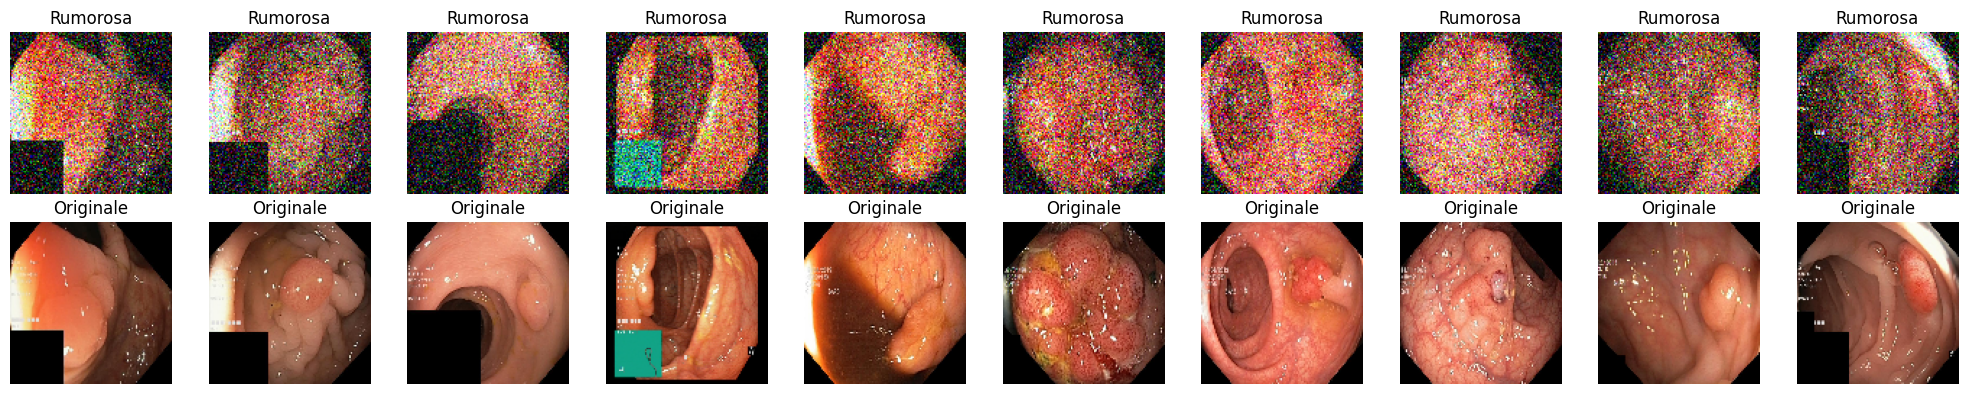

In [60]:
plot_side_by_side(kvasir_noise, kvasir_dataset, n=10)

In [61]:
ridnet_mia = load_model('new_RIDNETx128.keras')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'block_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'block_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'block_10', however the layer does not have a `bui

In [62]:
def EAM(input):

  x=Conv2D(64, (3,3), dilation_rate=1,padding='same',activation='relu')(input)
  x=Conv2D(64, (3,3), dilation_rate=2,padding='same',activation='relu')(x)

  y=Conv2D(64, (3,3), dilation_rate=3,padding='same',activation='relu')(input)
  y=Conv2D(64, (3,3), dilation_rate=4,padding='same',activation='relu')(y)

  z=Concatenate(axis=-1)([x,y])
  z=Conv2D(64, (3,3),padding='same',activation='relu')(z)
  add_1=Add()([z, input])

  z=Conv2D(64, (3,3),padding='same',activation='relu')(add_1)
  z=Conv2D(64, (3,3),padding='same')(z)
  add_2=Add()([z,add_1])
  add_2 = Activation('relu')(add_2)

  z=Conv2D(64, (3,3),padding='same',activation='relu')(add_2)
  z=Conv2D(64, (3,3),padding='same',activation='relu')(z)
  z=Conv2D(64, (1,1),padding='same')(z)
  add_3=Add()([z,add_2])
  add_3 = Activation('relu')(add_3)


  z = GlobalAveragePooling2D()(add_3)
  z = Lambda(lambda x: tf.expand_dims(tf.expand_dims(x, 1), 1))(z)
  z=Conv2D(4, (3,3),padding='same',activation='relu')(z)
  z=Conv2D(64, (3,3),padding='same',activation='sigmoid')(z)
  mul=Multiply()([z, add_3])

  return mul

def RIDNET():

  input = Input((None, None, 3),name='input')
  feat_extraction =Conv2D(64, (3,3),padding='same')(input)
  eam_1=EAM(feat_extraction)
  eam_2=EAM(eam_1)
  eam_3=EAM(eam_2)
  eam_4=EAM(eam_3)
  x=Conv2D(3, (3,3),padding='same')(eam_4)
  add_2=Add()([x, input])

  model=Model(input,add_2)

  return model

In [63]:
ridnet_altrp = RIDNET()
ridnet_altrp.load_weights('ridnet.h5')

In [64]:
decoded_ridnet_mia = ridnet_mia.predict(kvasir_noise)

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step


In [65]:
decoded_altrp = ridnet_altrp.predict(kvasir_noise)

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 360ms/step


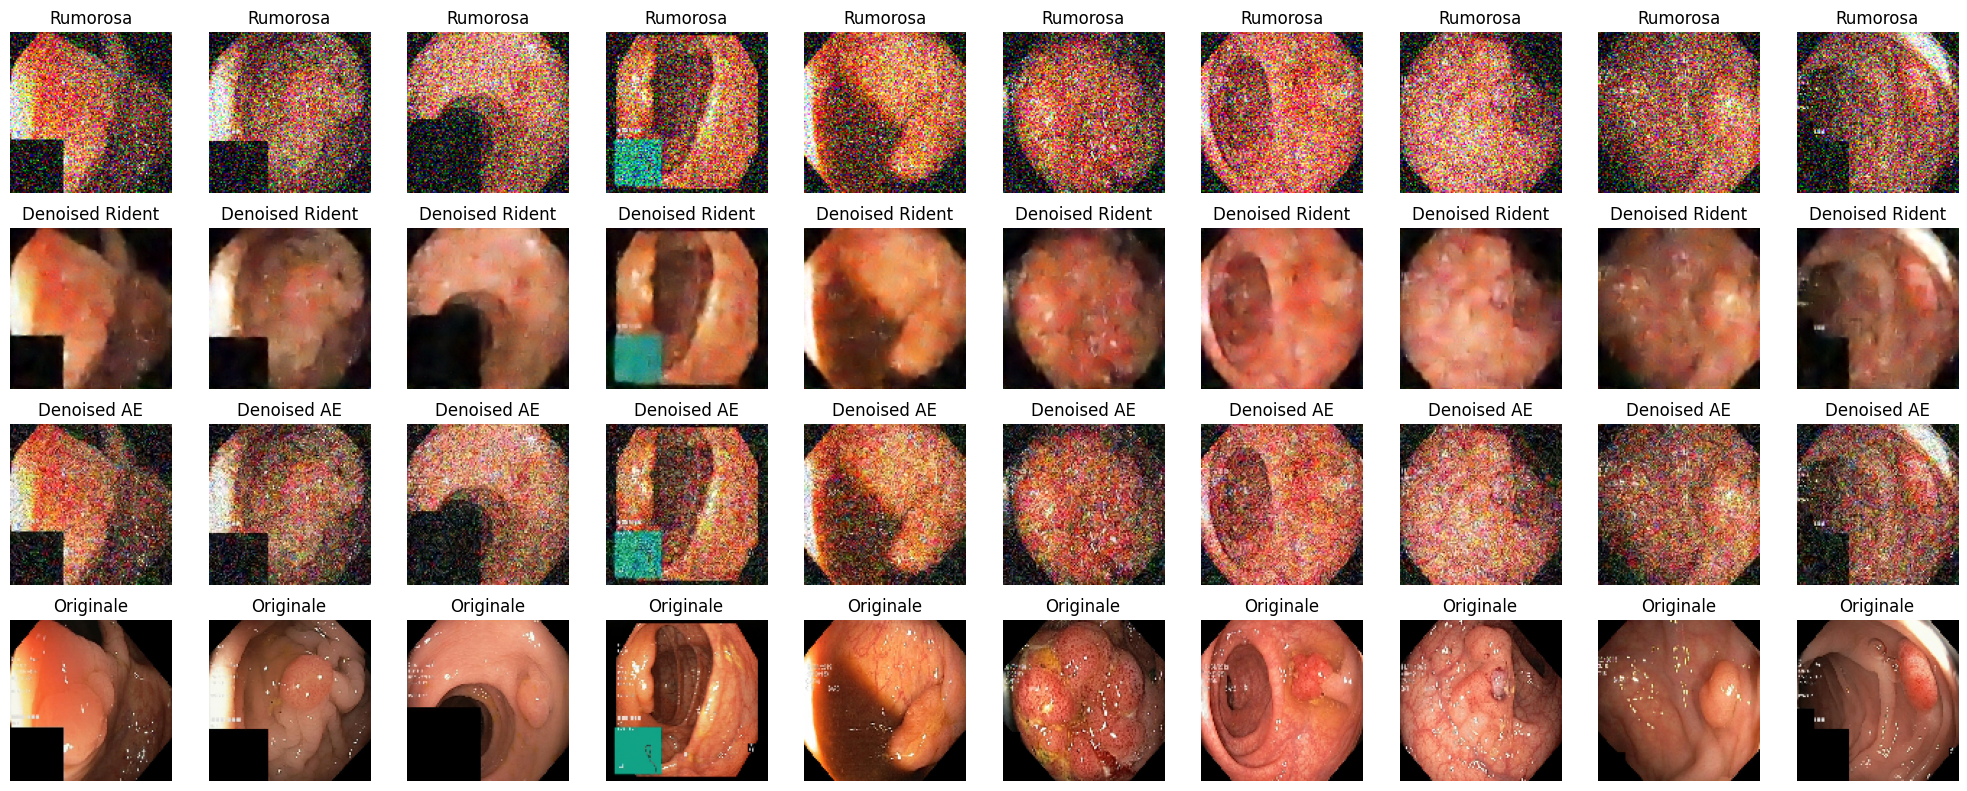

In [67]:
plot_denoising_results(kvasir_noise, decoded_ridnet_mia, decoded_altrp, kvasir_dataset, n=10)

In [68]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from collections import defaultdict

In [69]:
def calculate_psnr(img1, img2):
    """
    Calcola il PSNR tra due immagini TensorFlow (img1 e img2).
    Entrambe devono essere float32 e normalizzate (0-1) o in uint8 (0-255).
    """
    return tf.image.psnr(img1, img2, max_val=1.0 if img1.dtype.is_floating else 255.0).numpy()

In [70]:
def plot_psnr_vs_noise(psnr_dict):
    levels = sorted(psnr_dict.keys())
    psnr_values = [psnr_dict[level] for level in levels]

    plt.figure(figsize=(8, 5))
    plt.plot(levels, psnr_values, marker='o')
    plt.xlabel("Fattore di rumore")
    plt.ylabel("PSNR medio (dB)")
    plt.title("PSNR vs Livello di Rumore")
    plt.grid(True)
    plt.show()

In [71]:
def psnr_by_noise_level(noisy_images, original_images, noise_levels):
    psnr_dict = defaultdict(list)

    for noisy, original, level in zip(noisy_images, original_images, noise_levels):
        psnr = calculate_psnr(tf.convert_to_tensor(noisy), tf.convert_to_tensor(original))
        psnr_dict[level].append(psnr)

    # Calcola media per ogni livello di rumore
    avg_psnr_by_level = {level: np.mean(values) for level, values in psnr_dict.items()}

    return avg_psnr_by_level

In [73]:
psnr_ridnet = [psnr(kvasir_noise[i].numpy(), decoded_ridnet_mia[i], data_range=1.0) for i in range(len(kvasir_noise))]
psnr_autoen = [psnr(kvasir_noise[i].numpy(), decoded_altrp[i], data_range=1.0) for i in range(len(kvasir_noise))]

In [74]:
# (Facoltativo) Media PSNR
print(f"Media PSNR ridnet: {np.mean(psnr_ridnet):.2f} dB")
# (Facoltativo) Media PSNR
print(f"Media PSNR autoencoder: {np.mean(psnr_autoen):.2f} dB")

Media PSNR ridnet: 12.56 dB
Media PSNR autoencoder: 16.07 dB


In [78]:
def model_psnr_predict(original_images, noise_levels = [0.1, 0.2, 0.3, 0.4]):
  all_r_psnr = []
  all_a_psnr = []
  for level in noise_levels:
    print("Noise level: " + str(level))
    noisy_images = add_noise_2(original_images, level)
    print("noisy")
    #Ridnet predict psnr
    decoded = ridnet_mia.predict(noisy_images)
    print("decode r")
    psnrs = [psnr(noisy_images[i].numpy(), decoded[i], data_range=1.0) for i in range(len(noisy_images))]
    print("psnr r")
    all_r_psnr.append(np.mean(psnrs))
    print("all psnr r")

    #Ridnet predict psnr
    decoded = ridnet_altrp.predict(noisy_images)
    psnrs = [psnr(noisy_images[i].numpy(), decoded[i], data_range=1.0) for i in range(len(noisy_images))]
    all_a_psnr.append(np.mean(psnrs))

  return all_r_psnr, all_a_psnr

In [79]:
noise_levels = np.arange(0.1, 0.5, 0.1)
print(noise_levels)

[0.1 0.2 0.3 0.4]


In [80]:

all_ridnet_psnr, all_autoen_psnr = model_psnr_predict(kvasir_dataset, noise_levels)


Noise level: 0.1
noisy
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step
decode r
psnr r
all psnr r
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step
Noise level: 0.2
noisy
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step
decode r
psnr r
all psnr r
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 311ms/step
Noise level: 0.30000000000000004
noisy
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step
decode r
psnr r
all psnr r
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step
Noise level: 0.4
noisy
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step
decode r
psnr r
all psnr r
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 295ms/step


/tmp/ipython-input-81-2202077041.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


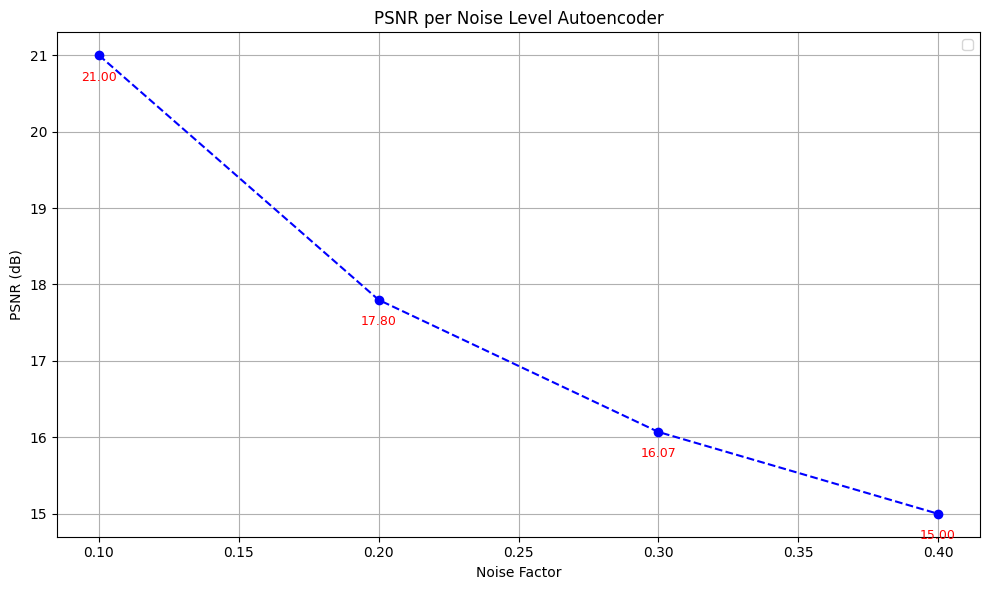

In [81]:
# PSNR Autoencoder

plt.figure(figsize=(10, 6))

plt.plot(noise_levels, all_autoen_psnr, marker='o', linestyle='--', color='b')
for x, y in zip(noise_levels, all_autoen_psnr):
    plt.text(x, y - 0.2, f"{y:.2f}", ha='center', va='top', fontsize=9, color='r')

plt.title("PSNR per Noise Level Autoencoder")
plt.xlabel("Noise Factor")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-82-1306265541.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


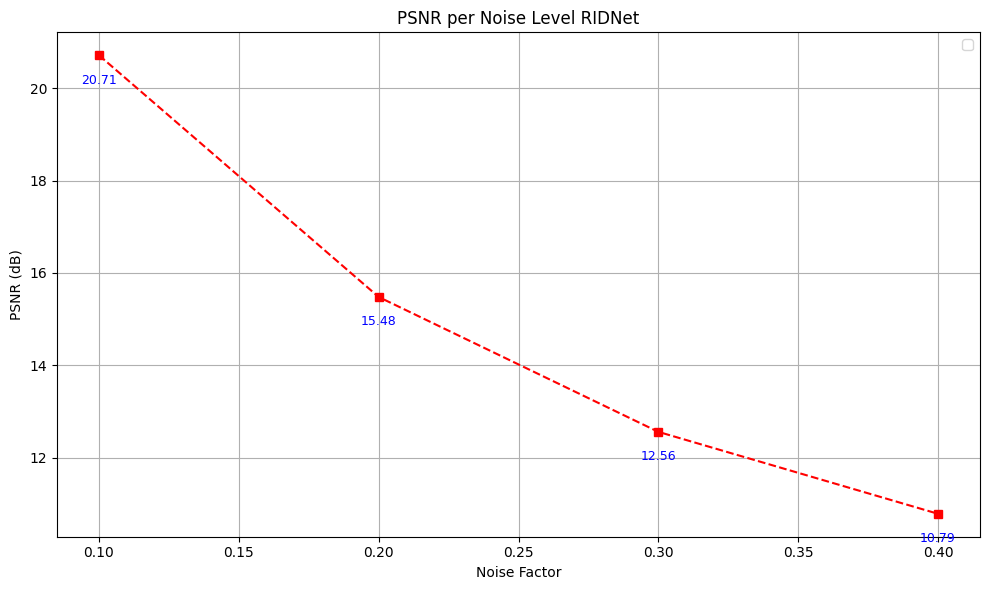

In [82]:
#PSNR RIDNet
plt.figure(figsize=(10, 6))
plt.plot(noise_levels, all_ridnet_psnr, marker='s', linestyle='--', color='r')
for x, y in zip(noise_levels, all_ridnet_psnr):
    plt.text(x, y - 0.4, f"{y:.2f}", ha='center', va='top', fontsize=9, color='b')

plt.title("PSNR per Noise Level RIDNet")
plt.xlabel("Noise Factor")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

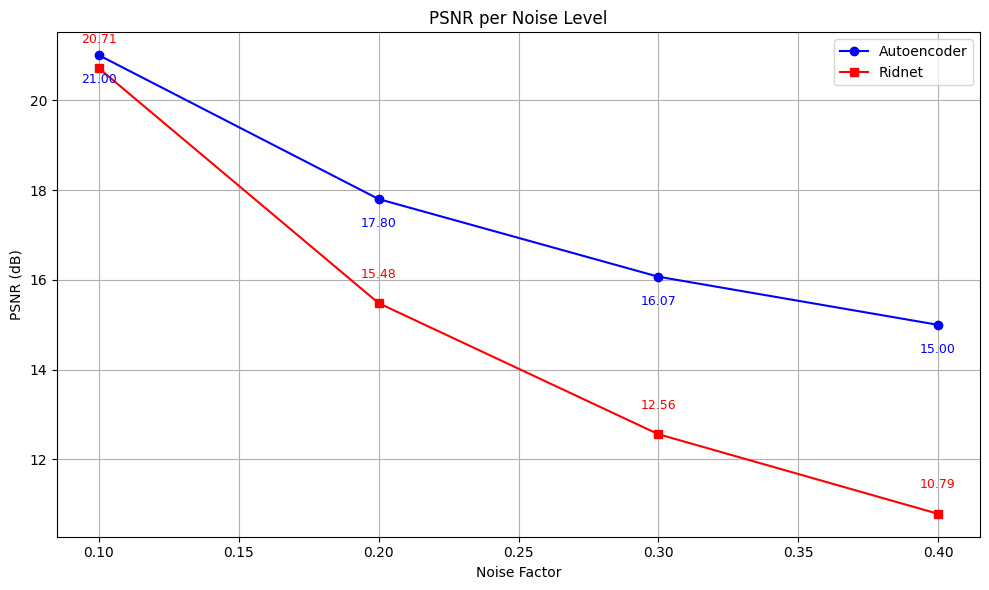

In [83]:
# Primo array

plt.figure(figsize=(10, 6))

plt.plot(noise_levels, all_autoen_psnr, marker='o', linestyle='-', color='b', label='Autoencoder')
for x, y in zip(noise_levels, all_autoen_psnr):
    plt.text(x, y - 0.4, f"{y:.2f}", ha='center', va='top', fontsize=9, color='b')

# Secondo array
plt.plot(noise_levels, all_ridnet_psnr, marker='s', linestyle='-', color='r', label='Ridnet')
for x, y in zip(noise_levels, all_ridnet_psnr):
    plt.text(x, y + 0.5, f"{y:.2f}", ha='center', va='bottom', fontsize=9, color='r')

plt.title("PSNR per Noise Level")
plt.xlabel("Noise Factor")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()